# Applied Machine Learning - Homework 2
## Advanced Topics: ML Diagnostics, Optimization & Model Validation

### Learning Objectives
By completing this homework, you will:
1. Implement advanced optimization algorithms (Momentum, Adam)
2. Diagnose and address bias-variance trade-offs
3. Apply cross-validation techniques for model evaluation
4. Detect and mitigate overfitting/underfitting
5. Compare different optimization strategies
6. Build diagnostic tools for ML model analysis

### Prerequisites
This homework builds on concepts from Homework 1. Ensure you have:
- Completed the neural network implementation from Homework 1
- Understanding of loss functions and gradient descent
- Familiarity with forward/backward propagation

### Instructions
- Complete all TODO sections marked with `# TODO: [Task Description]`
- Run all cells to ensure your implementation works
- Answer the reflection questions in markdown cells
- **Build upon the neural network from Homework 1**

---

## Setup and Imports

In [3]:
# Essential imports for advanced ML concepts
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn available for comparison and validation")

✅ All imports successful!
NumPy version: 2.4.2
Scikit-learn available for comparison and validation


## Enhanced Neural Network with Advanced Optimizers

Let's extend our neural network from Homework 1 with advanced optimization algorithms.

In [4]:
class AdvancedNeuralNetwork:
    """Enhanced neural network with multiple optimization algorithms."""
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01, optimizer='sgd'):
        """
        Initialize the neural network with advanced optimizers.
        
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units
            output_size: Number of output units
            learning_rate: Learning rate for optimization
            optimizer: Optimization algorithm ('sgd', 'momentum', 'adam')
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        
        # Initialize weights and biases (He initialization for ReLU)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Initialize optimizer-specific parameters
        self._initialize_optimizer()
        
        # Training history
        self.loss_history = []
        self.train_accuracy_history = []
        self.val_accuracy_history = []
        
    def _initialize_optimizer(self):
        """Initialize optimizer-specific parameters."""
        if self.optimizer == 'momentum':
            self.beta = 0.9
            self.vW1 = np.zeros_like(self.W1)
            self.vb1 = np.zeros_like(self.b1)
            self.vW2 = np.zeros_like(self.W2)
            self.vb2 = np.zeros_like(self.b2)
            
        elif self.optimizer == 'adam':
            self.beta1 = 0.9
            self.beta2 = 0.999
            self.epsilon = 1e-8
            self.t = 0  # time step
            
            # First moment estimates
            self.mW1 = np.zeros_like(self.W1)
            self.mb1 = np.zeros_like(self.b1)
            self.mW2 = np.zeros_like(self.W2)
            self.mb2 = np.zeros_like(self.b2)
            
            # Second moment estimates
            self.vW1 = np.zeros_like(self.W1)
            self.vb1 = np.zeros_like(self.b1)
            self.vW2 = np.zeros_like(self.W2)
            self.vb2 = np.zeros_like(self.b2)
    
    def sigmoid(self, x):
        """Sigmoid activation function with numerical stability."""
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))
    
    def relu(self, x):
        """ReLU activation function."""
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU function."""
        return (x > 0).astype(float)
    
    def forward(self, X):
        """Forward propagation through the network."""
        # Layer 1
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        
        # Layer 2
        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)
        
        # Store for backpropagation
        self.cache = {
            'X': X,
            'z1': z1,
            'a1': a1,
            'z2': z2,
            'a2': a2
        }
        
        return a2
    
    def backward(self, X, y, output):
        """Backward propagation with advanced optimizers."""
        m = X.shape[0]
        
        # Get cached values
        a1 = self.cache['a1']
        z1 = self.cache['z1']
        z2 = self.cache['z2']
        
        # Compute gradients
        dz2 = output - y
        dW2 = (1/m) * a1.T @ dz2
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(z1)
        dW1 = (1/m) * X.T @ dz1
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        # Apply optimizer
        self._apply_optimizer(dW1, db1, dW2, db2)
    
    def _apply_optimizer(self, dW1, db1, dW2, db2):
        """Apply the specified optimization algorithm."""
        if self.optimizer == 'sgd':
            # Standard gradient descent
            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2
            
        elif self.optimizer == 'momentum':
            # Momentum update rule:
            # v = beta * v + (1 - beta) * gradient
            # parameter = parameter - learning_rate * v
            
            # Update velocity and parameters for W1
            self.vW1 = self.beta * self.vW1 + (1 - self.beta) * dW1
            self.W1 -= self.learning_rate * self.vW1
            
            # Update velocity and parameters for b1
            self.vb1 = self.beta * self.vb1 + (1 - self.beta) * db1
            self.b1 -= self.learning_rate * self.vb1
            
            # Update velocity and parameters for W2
            self.vW2 = self.beta * self.vW2 + (1 - self.beta) * dW2
            self.W2 -= self.learning_rate * self.vW2
            
            # Update velocity and parameters for b2
            self.vb2 = self.beta * self.vb2 + (1 - self.beta) * db2
            self.b2 -= self.learning_rate * self.vb2
            
        elif self.optimizer == 'adam':
            self.t += 1
            # Adam update rule:
            # m = beta1 * m + (1 - beta1) * gradient
            # v = beta2 * v + (1 - beta2) * gradient²
            # m_corrected = m / (1 - beta1^t)
            # v_corrected = v / (1 - beta2^t)
            # parameter = parameter - learning_rate * m_corrected / (sqrt(v_corrected) + epsilon)
            
            # Update biased first moment estimate
            self.mW1 = self.beta1 * self.mW1 + (1 - self.beta1) * dW1
            self.mb1 = self.beta1 * self.mb1 + (1 - self.beta1) * db1
            self.mW2 = self.beta1 * self.mW2 + (1 - self.beta1) * dW2
            self.mb2 = self.beta1 * self.mb2 + (1 - self.beta1) * db2
            
            # Update biased second raw moment estimate
            self.vW1 = self.beta2 * self.vW1 + (1 - self.beta2) * (dW1 ** 2)
            self.vb1 = self.beta2 * self.vb1 + (1 - self.beta2) * (db1 ** 2)
            self.vW2 = self.beta2 * self.vW2 + (1 - self.beta2) * (dW2 ** 2)
            self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (db2 ** 2)
            
            # Compute bias-corrected first moment estimate
            mW1_corr = self.mW1 / (1 - self.beta1 ** self.t)
            mb1_corr = self.mb1 / (1 - self.beta1 ** self.t)
            mW2_corr = self.mW2 / (1 - self.beta1 ** self.t)
            mb2_corr = self.mb2 / (1 - self.beta1 ** self.t)
            
            # Compute bias-corrected second raw moment estimate
            vW1_corr = self.vW1 / (1 - self.beta2 ** self.t)
            vb1_corr = self.vb1 / (1 - self.beta2 ** self.t)
            vW2_corr = self.vW2 / (1 - self.beta2 ** self.t)
            vb2_corr = self.vb2 / (1 - self.beta2 ** self.t)
            
            # Update parameters
            self.W1 -= self.learning_rate * mW1_corr / (np.sqrt(vW1_corr) + self.epsilon)
            self.b1 -= self.learning_rate * mb1_corr / (np.sqrt(vb1_corr) + self.epsilon)
            self.W2 -= self.learning_rate * mW2_corr / (np.sqrt(vW2_corr) + self.epsilon)
            self.b2 -= self.learning_rate * mb2_corr / (np.sqrt(vb2_corr) + self.epsilon)
    
    def binary_cross_entropy(self, y_true, y_pred):
        """Calculate binary cross-entropy loss."""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def accuracy(self, y_true, y_pred):
        """Calculate accuracy for binary classification."""
        predictions = (y_pred > 0.5).astype(int)
        return np.mean(predictions == y_true)
    
    def train(self, X_train, y_train, X_val=None, y_val=None, epochs=1000, verbose=True):
        """Train the neural network with validation monitoring."""
        for epoch in range(epochs):
            # Training
            train_output = self.forward(X_train)
            train_loss = self.binary_cross_entropy(y_train, train_output)
            train_accuracy = self.accuracy(y_train, train_output)
            
            self.backward(X_train, y_train, train_output)
            
            # Store training metrics
            self.loss_history.append(train_loss)
            self.train_accuracy_history.append(train_accuracy)
            
            # Validation
            if X_val is not None and y_val is not None:
                val_output = self.forward(X_val)
                val_accuracy = self.accuracy(y_val, val_output)
                self.val_accuracy_history.append(val_accuracy)
            
            # Progress reporting
            if verbose and epoch % 100 == 0:
                if X_val is not None:
                    print(f"Epoch {epoch}/{epochs}, Loss: {train_loss:.4f}, "
                          f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")
                else:
                    print(f"Epoch {epoch}/{epochs}, Loss: {train_loss:.4f}, "
                          f"Train Acc: {train_accuracy:.4f}")
    
    def predict(self, X):
        """Make predictions on new data."""
        return self.forward(X)

print("✅ Advanced Neural Network class defined!")
print("⚠️  Momentum and Adam optimizers need to be implemented.")

✅ Advanced Neural Network class defined!
⚠️  Momentum and Adam optimizers need to be implemented.


---
# Part 1: Advanced Optimization Algorithms

Implement and compare different optimization algorithms.

In [5]:
def create_challenging_dataset():
    """Create a more challenging dataset for optimization comparison."""
    # Generate a complex classification dataset
    X, y = make_classification(
        n_samples=2000,
        n_features=10,
        n_informative=8,
        n_redundant=2,
        n_clusters_per_class=2,
        flip_y=0.1,  # Add some noise
        random_state=42
    )
    
    # Split the data
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    # Reshape labels
    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

# Create the challenging dataset
X_train, X_val, X_test, y_train, y_val, y_test, scaler = create_challenging_dataset()

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Class distribution - Train: {np.bincount(y_train.flatten())}")
print(f"Class distribution - Val: {np.bincount(y_val.flatten())}")
print(f"Class distribution - Test: {np.bincount(y_test.flatten())}")

Training data shape: (1200, 10)
Validation data shape: (400, 10)
Test data shape: (400, 10)
Features: 10
Class distribution - Train: [598 602]
Class distribution - Val: [195 205]
Class distribution - Test: [205 195]


### Task 1.1: Implement and Compare Optimizers

Training networks with different optimizers...

Training with SGD optimizer...
Final - Train: 0.7108, Val: 0.7175, Test: 0.7350

Training with MOMENTUM optimizer...
Final - Train: 0.7083, Val: 0.6925, Test: 0.7425

Training with ADAM optimizer...
Final - Train: 0.9033, Val: 0.8450, Test: 0.8450


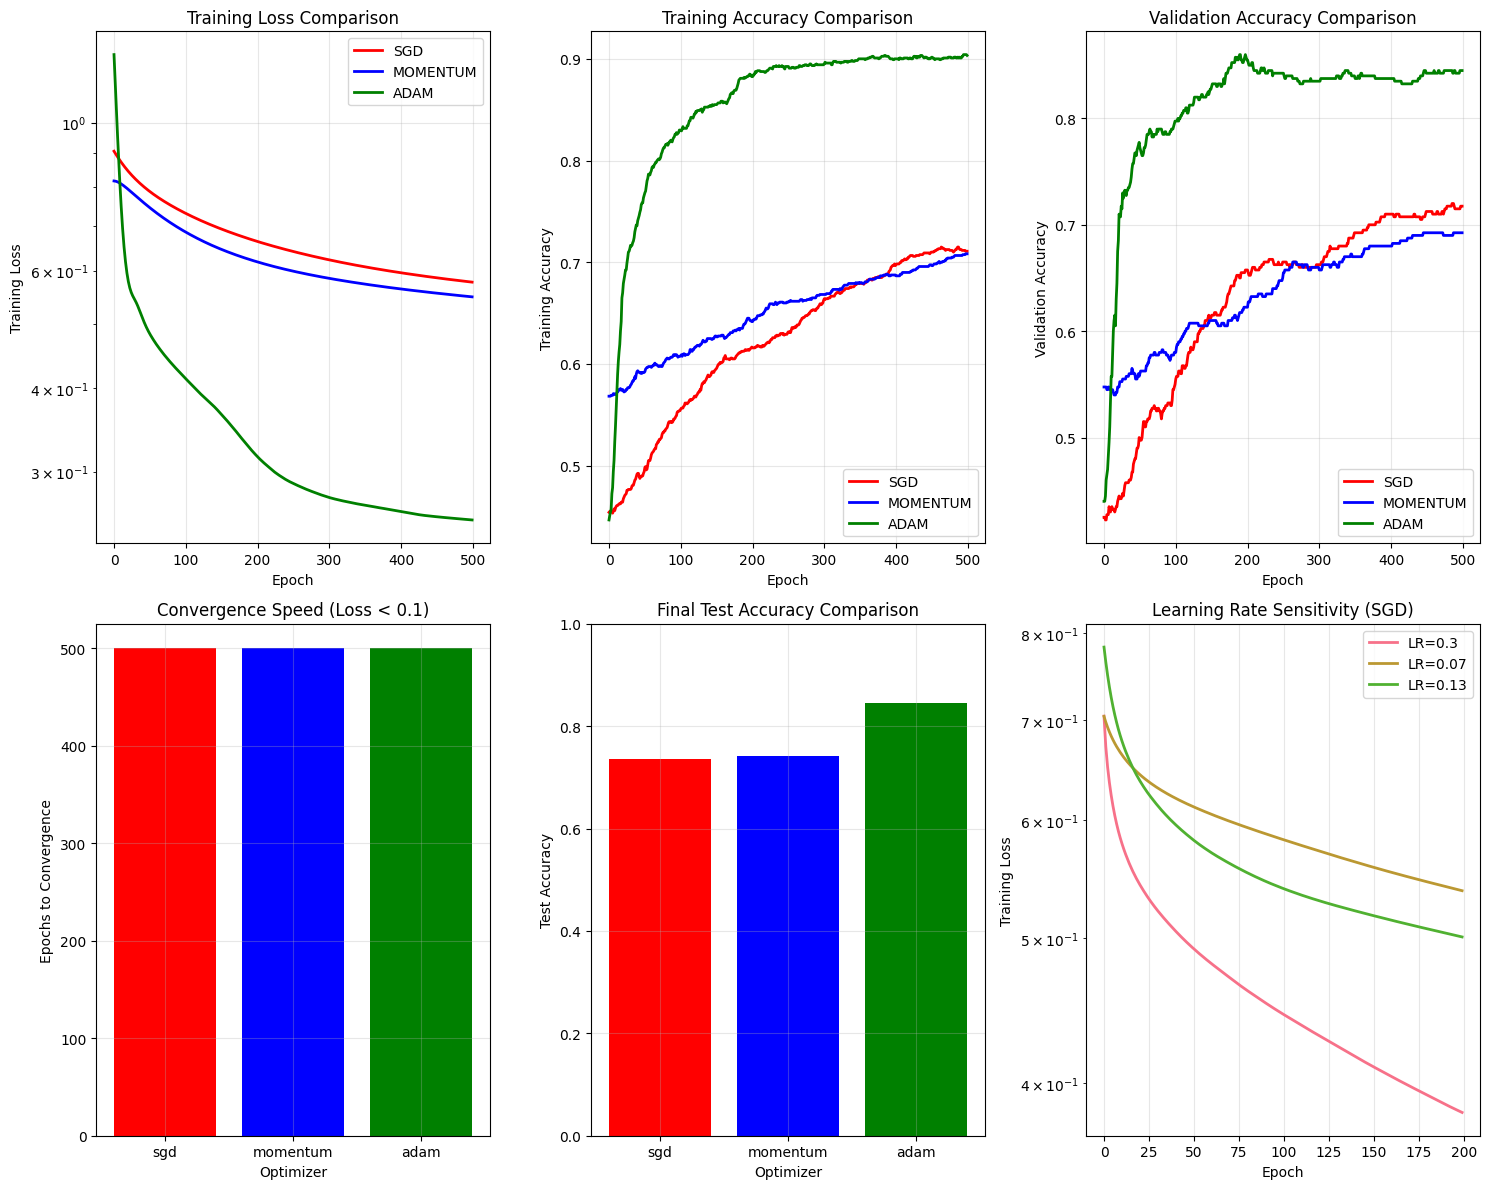

In [15]:
def compare_optimizers():
    """Compare different optimization algorithms."""
    
    optimizers = ['sgd', 'momentum', 'adam']
    networks = {}
    colors = ['red', 'blue', 'green']
    
    plt.figure(figsize=(15, 12))
    
    print("Training networks with different optimizers...")
    print("=" * 50)
    
    for i, optimizer in enumerate(optimizers):
        print(f"\nTraining with {optimizer.upper()} optimizer...")
        
        # Create and train network
        nn = AdvancedNeuralNetwork(
            input_size=10, 
            hidden_size=15, 
            output_size=1, 
            learning_rate=0.01,
            optimizer=optimizer
        )
        
        try:
            nn.train(X_train, y_train, X_val, y_val, epochs=500, verbose=False)
            networks[optimizer] = nn
            
            # Final performance
            train_pred = nn.predict(X_train)
            val_pred = nn.predict(X_val)
            test_pred = nn.predict(X_test)
            
            train_acc = nn.accuracy(y_train, train_pred)
            val_acc = nn.accuracy(y_val, val_pred)
            test_acc = nn.accuracy(y_test, test_pred)
            
            print(f"Final - Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}")
            
        except Exception as e:
            print(f"❌ Failed to train with {optimizer}: {str(e)}")
            print(f"💡 Check your {optimizer} implementation!")
            continue
    
    # Plot 1: Training Loss Comparison
    plt.subplot(2, 3, 1)
    for i, (optimizer, nn) in enumerate(networks.items()):
        plt.plot(nn.loss_history, label=f'{optimizer.upper()}', color=colors[i], linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Plot 2: Training Accuracy
    plt.subplot(2, 3, 2)
    for i, (optimizer, nn) in enumerate(networks.items()):
        plt.plot(nn.train_accuracy_history, label=f'{optimizer.upper()}', color=colors[i], linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Training Accuracy')
    plt.title('Training Accuracy Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Validation Accuracy
    plt.subplot(2, 3, 3)
    for i, (optimizer, nn) in enumerate(networks.items()):
        plt.plot(nn.val_accuracy_history, label=f'{optimizer.upper()}', color=colors[i], linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Convergence Speed Analysis
    plt.subplot(2, 3, 4)
    target_loss = 0.1  # Define convergence threshold
    convergence_epochs = []
    
    for optimizer, nn in networks.items():
        # Find first epoch where loss < target_loss
        converged_at = None
        for epoch, loss in enumerate(nn.loss_history):
            if loss < target_loss:
                converged_at = epoch
                break
        
        if converged_at is not None:
            convergence_epochs.append(converged_at)
        else:
            convergence_epochs.append(len(nn.loss_history))  # Didn't converge
    
    if convergence_epochs:
        plt.bar(list(networks.keys()), convergence_epochs, color=colors[:len(networks)])
        plt.xlabel('Optimizer')
        plt.ylabel('Epochs to Convergence')
        plt.title(f'Convergence Speed (Loss < {target_loss})')
        plt.grid(True, alpha=0.3)
    
    # Plot 5: Final Performance Bar Chart
    plt.subplot(2, 3, 5)
    performance_data = []
    
    for optimizer, nn in networks.items():
        test_pred = nn.predict(X_test)
        test_acc = nn.accuracy(y_test, test_pred)
        performance_data.append(test_acc)
    
    if performance_data:
        plt.bar(list(networks.keys()), performance_data, color=colors[:len(networks)])
        plt.xlabel('Optimizer')
        plt.ylabel('Test Accuracy')
        plt.title('Final Test Accuracy Comparison')
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 1])
    
    # Plot 6: Learning Rate Sensitivity (for implemented optimizers)
    plt.subplot(2, 3, 6)
    
    # TODO: Test different learning rates for each optimizer
    #learning_rates = [0.001, 0.01, 0.1]
    #learning_rates = [0.02, 0.1, 0.05]
    learning_rates = [0.30, 0.07, 0.13]

    
    for lr in learning_rates:
        # Test with SGD (which should always work)
        nn_test = AdvancedNeuralNetwork(
            input_size=10, hidden_size=15, output_size=1, 
            learning_rate=lr, optimizer='sgd'
        )
        nn_test.train(X_train, y_train, epochs=200, verbose=False)
        plt.plot(nn_test.loss_history, label=f'LR={lr}', linewidth=2)
    
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Learning Rate Sensitivity (SGD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return networks

# Run optimizer comparison
trained_networks = compare_optimizers()

### Reflection Question 1.1
**Answer the following questions:**

1. Which optimizer converges fastest? Why do you think this is the case?
2. How do the different optimizers handle noisy gradients differently?
3. What are the advantages and disadvantages of each optimization algorithm?
4. In what scenarios would you choose each optimizer?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->
- Adam converges fastest because its adaptive learning rates and moment estimates accelerate and stabilize updates.  
- SGD applies raw noisy gradients causing unstable steps, Momentum smooths and accelerates updates by accumulating past gradients, and Adam adaptively scales updates using first and second moment estimates, making it robust to noise.  
- SGD: simple and memory-efficient but slow and sensitive to learning rate, Momentum, faster and less oscillatory but requires momentum and learning-rate tuning; Adam: fast and robust with less tuning but may generalize worse and uses more memory.  
- Use SGD when you want simple, memory-light training or better generalization, use Momentum for deeper networks where acceleration and reduced oscillation help, use Adam for rapid prototyping, noisy or sparse gradients, or when you need an optimizer that requires less LR tuning.

## Part 1 To-Do List ✅

Before moving to Part 2, ensure you have completed the following tasks:

1. **Implement Momentum Optimizer** ✏️
   - [ ] Complete the momentum update rule in `_apply_optimizer()` method
   - [ ] Update velocity for W1 and b1
   - [ ] Update velocity for W2 and b2
   - [ ] Apply momentum updates to all parameters

2. **Implement Adam Optimizer** ✏️
   - [ ] Implement first moment (m) updates for all parameters
   - [ ] Implement second moment (v) updates for all parameters
   - [ ] Apply bias correction for both moments
   - [ ] Update all parameters using Adam formula

3. **Compare Optimizers** 📊
   - [ ] Run the optimizer comparison experiment
   - [ ] Observe convergence speeds of SGD, Momentum, and Adam
   - [ ] Analyze the training loss curves
   - [ ] Check validation accuracy differences

4. **Test Learning Rate Sensitivity** 🎯
   - [ ] Experiment with different learning rates (0.001, 0.01, 0.1)
   - [ ] Observe how each optimizer handles different learning rates
   - [ ] Note which optimizer is most robust to learning rate changes

5. **Answer Reflection Questions** 💭
   - [ ] Explain which optimizer converges fastest and why
   - [ ] Describe how different optimizers handle noisy gradients
   - [ ] List advantages and disadvantages of each optimization algorithm
   - [ ] Provide scenarios where you would choose each optimizer

**Debugging Tips:**
- If momentum isn't working, check that you're updating the velocity terms before applying them
- For Adam, ensure you're incrementing the time step `t` and applying bias correction
- Verify that your gradients are being computed correctly in the backward pass
- If training fails, start with a smaller learning rate

---
# Part 2: ML Diagnostics - Bias vs Variance

Implement diagnostic tools to identify and address bias-variance trade-offs.

In [14]:
class MLDiagnostics:
    """Tools for diagnosing ML model performance issues."""
    
    @staticmethod
    def learning_curves(model_class, X_train, y_train, X_val, y_val, 
                       training_sizes=None, **model_params):
        """
        Generate learning curves to diagnose bias vs variance.
        
        Args:
            model_class: Class to instantiate (e.g., AdvancedNeuralNetwork)
            X_train, y_train: Training data
            X_val, y_val: Validation data
            training_sizes: Different training set sizes to try
            **model_params: Parameters to pass to model constructor
        """
        if training_sizes is None:
            training_sizes = np.linspace(0.1, 1.0, 10)
        
        train_scores = []
        val_scores = []
        train_losses = []
        val_losses = []
        
        for size in training_sizes:
            # Sample subset of training data
            n_samples = int(size * len(X_train))
            indices = np.random.choice(len(X_train), n_samples, replace=False)
            X_subset = X_train[indices]
            y_subset = y_train[indices]
            
            # Train model on subset
            model = model_class(**model_params)
            model.train(X_subset, y_subset, epochs=300, verbose=False)
            
            # Evaluate on both training subset and validation set
            train_pred = model.predict(X_subset)
            val_pred = model.predict(X_val)
            
            train_acc = model.accuracy(y_subset, train_pred)
            val_acc = model.accuracy(y_val, val_pred)
            
            train_loss = model.binary_cross_entropy(y_subset, train_pred)
            val_loss = model.binary_cross_entropy(y_val, val_pred)
            
            train_scores.append(train_acc)
            val_scores.append(val_acc)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            print(f"Size: {size:.2f}, Samples: {n_samples}, "
                  f"Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}")
        
        return training_sizes, train_scores, val_scores, train_losses, val_losses
    
    @staticmethod
    def bias_variance_analysis(X_train, y_train, X_test, y_test, 
                              model_complexities, n_bootstrap=10):
        """
        Perform bias-variance decomposition analysis.
        
        Args:
            X_train, y_train: Training data
            X_test, y_test: Test data
            model_complexities: List of model complexity parameters
            n_bootstrap: Number of bootstrap samples
        """
        results = []
        
        for complexity in model_complexities:
            predictions = []
            
            # TODO: Implement bootstrap sampling and prediction collection
            for i in range(n_bootstrap):
                # Create bootstrap sample
                indices = np.random.choice(len(X_train), len(X_train), replace=True)
                X_boot = X_train[indices]
                y_boot = y_train[indices]
                
                # Train model with current complexity
                model = AdvancedNeuralNetwork(
                    input_size=X_train.shape[1],
                    hidden_size=complexity,  # Use hidden_size as complexity measure
                    output_size=1,
                    learning_rate=0.01
                )
                
                model.train(X_boot, y_boot, epochs=200, verbose=False)
                pred = model.predict(X_test)
                predictions.append(pred)
            
            # Convert to numpy array
            predictions = np.array(predictions)  # Shape: (n_bootstrap, n_test_samples, 1)
            
            # Calculate bias and variance
            # TODO: Implement bias-variance decomposition
            # Mean prediction across bootstrap samples
            mean_pred = np.mean(predictions, axis=0)
            
            # Bias²: (mean_prediction - true_value)²
            bias_squared = np.mean((mean_pred - y_test) ** 2)
            
            # Variance: E[(prediction - mean_prediction)²]
            variance = np.mean(np.var(predictions, axis=0))
            
            # Total error approximation
            total_error = bias_squared + variance
            
            results.append({
                'complexity': complexity,
                'bias_squared': bias_squared,
                'variance': variance,
                'total_error': total_error
            })
            
            print(f"Complexity {complexity}: Bias²={bias_squared:.4f}, "
                  f"Variance={variance:.4f}, Total={total_error:.4f}")
        
        return results
    
    @staticmethod
    def diagnose_overfitting(train_history, val_history, threshold=0.05):
        """
        Diagnose overfitting from training history.
        
        Args:
            train_history: Training performance over time
            val_history: Validation performance over time
            threshold: Threshold for significant gap
        """
        if len(train_history) != len(val_history):
            return "Error: History lengths don't match"
        
        # TODO: Implement overfitting detection logic
        # Calculate the gap between training and validation performance
        final_gap = train_history[-1] - val_history[-1]
        
        # Check if validation performance plateaus or degrades
        val_trend = np.diff(val_history[-10:])  # Last 10 epochs
        declining_validation = np.mean(val_trend) < -0.001
        
        # Diagnosis
        if final_gap > threshold:
            if declining_validation:
                return "Strong Overfitting: Large gap + declining validation"
            else:
                return "Moderate Overfitting: Large gap but stable validation"
        else:
            if max(train_history) < 0.8:  # Arbitrary threshold for good performance
                return "Underfitting: Poor performance on both sets"
            else:
                return "Good Fit: Small gap and good performance"

print("✅ ML Diagnostics tools defined!")

✅ ML Diagnostics tools defined!


### Task 2.1: Generate Learning Curves


Analyzing learning curves for hidden_size = 5
Size: 0.20, Samples: 240, Train Acc: 0.863, Val Acc: 0.760
Size: 0.31, Samples: 377, Train Acc: 0.849, Val Acc: 0.802
Size: 0.43, Samples: 514, Train Acc: 0.846, Val Acc: 0.787
Size: 0.54, Samples: 651, Train Acc: 0.856, Val Acc: 0.830
Size: 0.66, Samples: 788, Train Acc: 0.830, Val Acc: 0.785
Size: 0.77, Samples: 925, Train Acc: 0.850, Val Acc: 0.830
Size: 0.89, Samples: 1062, Train Acc: 0.864, Val Acc: 0.830
Size: 1.00, Samples: 1200, Train Acc: 0.818, Val Acc: 0.823

Analyzing learning curves for hidden_size = 15
Size: 0.20, Samples: 240, Train Acc: 0.954, Val Acc: 0.780
Size: 0.31, Samples: 377, Train Acc: 0.923, Val Acc: 0.752
Size: 0.43, Samples: 514, Train Acc: 0.901, Val Acc: 0.820
Size: 0.54, Samples: 651, Train Acc: 0.900, Val Acc: 0.858
Size: 0.66, Samples: 788, Train Acc: 0.898, Val Acc: 0.848
Size: 0.77, Samples: 925, Train Acc: 0.918, Val Acc: 0.863
Size: 0.89, Samples: 1062, Train Acc: 0.910, Val Acc: 0.858
Size: 1.00, Sampl

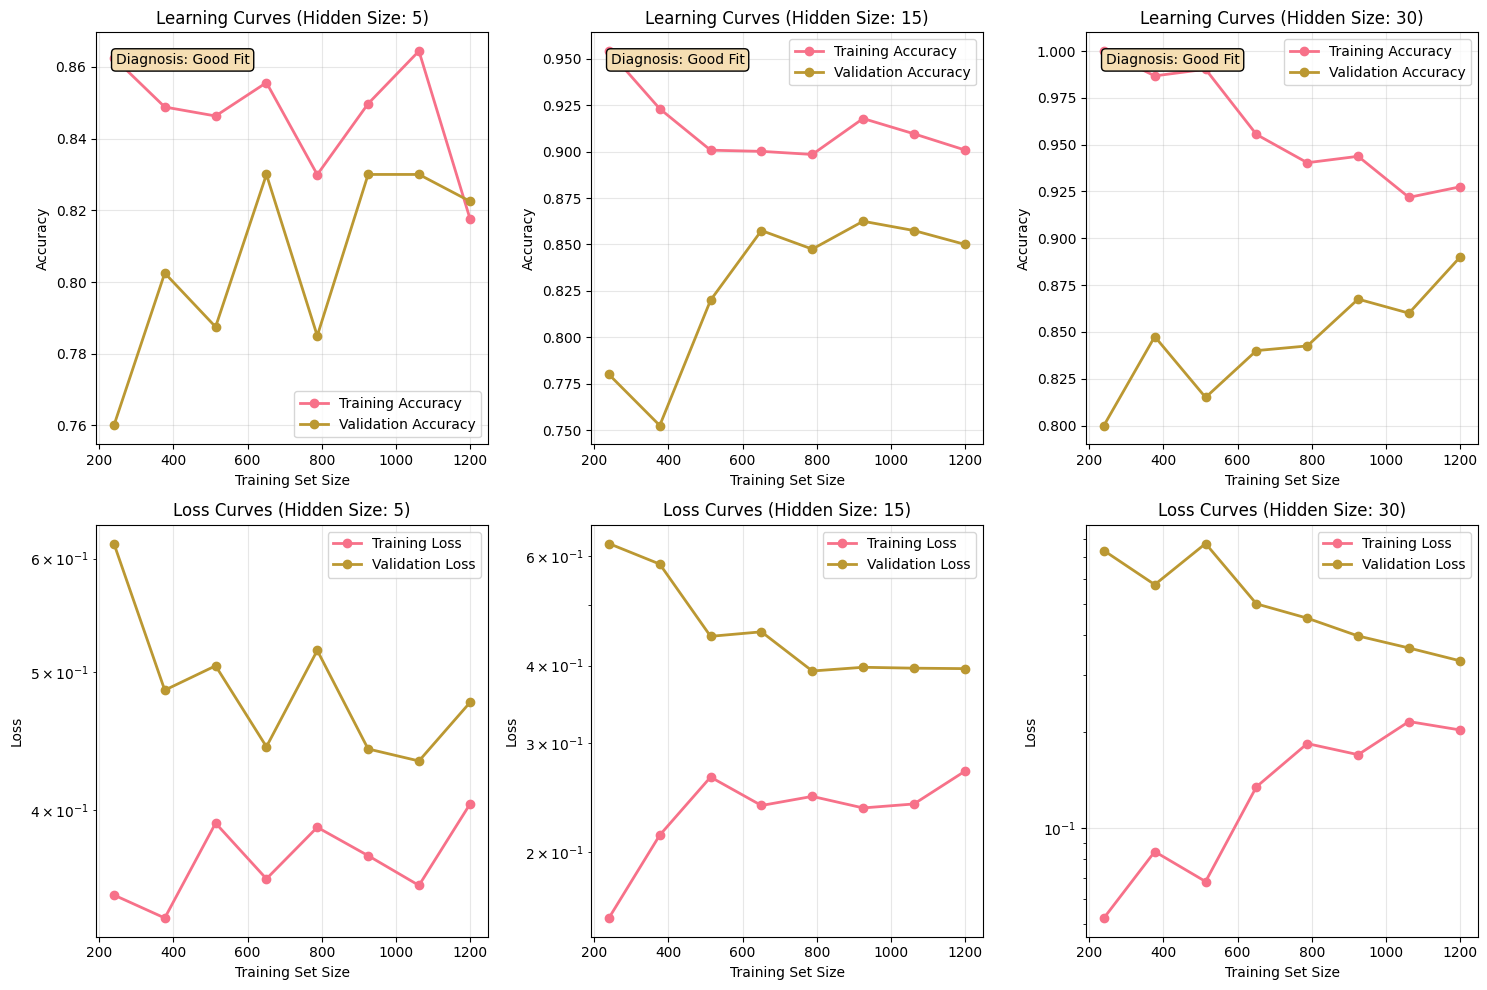

In [16]:
def analyze_learning_curves():
    """Generate and analyze learning curves for different model complexities."""
    
    plt.figure(figsize=(15, 10))
    
    # Test different model complexities
    complexities = [5, 15, 30]  # Hidden layer sizes
    
    for i, hidden_size in enumerate(complexities):
        print(f"\nAnalyzing learning curves for hidden_size = {hidden_size}")
        print("=" * 50)
        
        # Generate learning curves
        training_sizes, train_scores, val_scores, train_losses, val_losses = \
            MLDiagnostics.learning_curves(
                AdvancedNeuralNetwork,
                X_train, y_train, X_val, y_val,
                training_sizes=np.linspace(0.2, 1.0, 8),
                input_size=X_train.shape[1],
                hidden_size=hidden_size,
                output_size=1,
                learning_rate=0.01,
                optimizer='adam'  # Use Adam if implemented, otherwise 'sgd'
            )
        
        # Plot learning curves for accuracy
        plt.subplot(2, 3, i+1)
        sample_sizes = [int(size * len(X_train)) for size in training_sizes]
        
        plt.plot(sample_sizes, train_scores, 'o-', label='Training Accuracy', 
                linewidth=2, markersize=6)
        plt.plot(sample_sizes, val_scores, 'o-', label='Validation Accuracy', 
                linewidth=2, markersize=6)
        
        plt.xlabel('Training Set Size')
        plt.ylabel('Accuracy')
        plt.title(f'Learning Curves (Hidden Size: {hidden_size})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Diagnose the pattern
        final_gap = train_scores[-1] - val_scores[-1]
        
        if final_gap > 0.1:
            diagnosis = "Overfitting (High Variance)"
        elif max(val_scores) < 0.7:
            diagnosis = "Underfitting (High Bias)"
        else:
            diagnosis = "Good Fit"
        
        plt.text(0.05, 0.95, f"Diagnosis: {diagnosis}", 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle="round", facecolor='wheat'),
                verticalalignment='top')
        
        # Plot learning curves for loss
        plt.subplot(2, 3, i+4)
        plt.plot(sample_sizes, train_losses, 'o-', label='Training Loss', 
                linewidth=2, markersize=6)
        plt.plot(sample_sizes, val_losses, 'o-', label='Validation Loss', 
                linewidth=2, markersize=6)
        
        plt.xlabel('Training Set Size')
        plt.ylabel('Loss')
        plt.title(f'Loss Curves (Hidden Size: {hidden_size})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

# Run learning curve analysis
analyze_learning_curves()

### Task 2.2: Bias-Variance Decomposition

Performing Bias-Variance Decomposition Analysis...
This may take a few minutes...
Complexity 3: Bias²=0.2382, Variance=0.0061, Total=0.2443
Complexity 5: Bias²=0.2339, Variance=0.0105, Total=0.2444
Complexity 10: Bias²=0.2162, Variance=0.0150, Total=0.2312
Complexity 15: Bias²=0.2085, Variance=0.0126, Total=0.2211
Complexity 25: Bias²=0.2059, Variance=0.0121, Total=0.2181
Complexity 35: Bias²=0.1965, Variance=0.0128, Total=0.2092


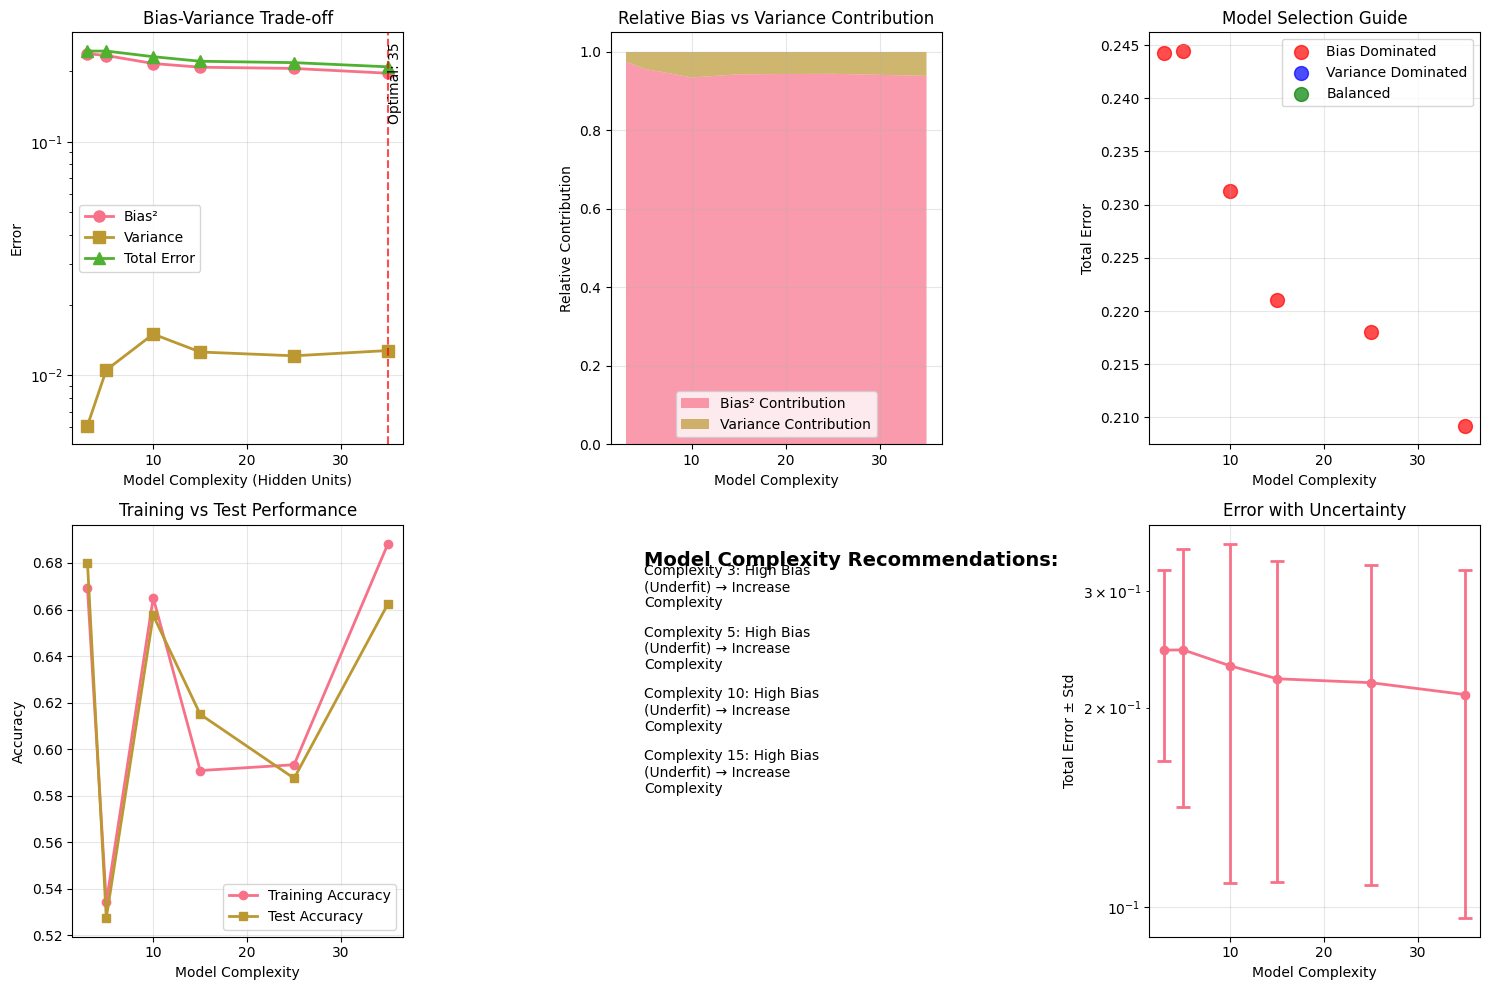


Bias-Variance Analysis Summary:
Optimal Complexity: 35 hidden units
Minimum Total Error: 0.2092
At optimal complexity - Bias²: 0.1965, Variance: 0.0128


In [17]:
def perform_bias_variance_analysis():
    """Perform comprehensive bias-variance analysis."""
    
    print("Performing Bias-Variance Decomposition Analysis...")
    print("This may take a few minutes...")
    print("=" * 50)
    
    # Test different model complexities
    complexities = [3, 5, 10, 15, 25, 35]
    
    # Perform bias-variance analysis
    results = MLDiagnostics.bias_variance_analysis(
        X_train, y_train, X_test, y_test,
        complexities, n_bootstrap=5  # Reduced for faster execution
    )
    
    # Extract data for plotting
    complexities_list = [r['complexity'] for r in results]
    bias_squared = [r['bias_squared'] for r in results]
    variance = [r['variance'] for r in results]
    total_error = [r['total_error'] for r in results]
    
    # Create comprehensive visualization
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Bias-Variance Trade-off
    plt.subplot(2, 3, 1)
    plt.plot(complexities_list, bias_squared, 'o-', label='Bias²', linewidth=2, markersize=8)
    plt.plot(complexities_list, variance, 's-', label='Variance', linewidth=2, markersize=8)
    plt.plot(complexities_list, total_error, '^-', label='Total Error', linewidth=2, markersize=8)
    
    plt.xlabel('Model Complexity (Hidden Units)')
    plt.ylabel('Error')
    plt.title('Bias-Variance Trade-off')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Find optimal complexity
    optimal_idx = np.argmin(total_error)
    optimal_complexity = complexities_list[optimal_idx]
    plt.axvline(x=optimal_complexity, color='red', linestyle='--', alpha=0.7)
    plt.text(optimal_complexity, max(total_error)*0.5, 
             f'Optimal: {optimal_complexity}', rotation=90)
    
    # Plot 2: Relative Contributions
    plt.subplot(2, 3, 2)
    relative_bias = np.array(bias_squared) / np.array(total_error)
    relative_variance = np.array(variance) / np.array(total_error)
    
    plt.stackplot(complexities_list, relative_bias, relative_variance, 
                 labels=['Bias² Contribution', 'Variance Contribution'],
                 alpha=0.7)
    plt.xlabel('Model Complexity')
    plt.ylabel('Relative Contribution')
    plt.title('Relative Bias vs Variance Contribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Model Selection Guide
    plt.subplot(2, 3, 3)
    
    # Create regions for different scenarios
    x = np.array(complexities_list)
    bias_dom = relative_bias > 0.6
    variance_dom = relative_variance > 0.6
    balanced = ~(bias_dom | variance_dom)
    
    plt.scatter(x[bias_dom], np.array(total_error)[bias_dom], 
               c='red', s=100, label='Bias Dominated', alpha=0.7)
    plt.scatter(x[variance_dom], np.array(total_error)[variance_dom], 
               c='blue', s=100, label='Variance Dominated', alpha=0.7)
    plt.scatter(x[balanced], np.array(total_error)[balanced], 
               c='green', s=100, label='Balanced', alpha=0.7)
    
    plt.xlabel('Model Complexity')
    plt.ylabel('Total Error')
    plt.title('Model Selection Guide')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Training vs Test Performance
    plt.subplot(2, 3, 4)
    
    # Train models with different complexities and get their performance
    train_performances = []
    test_performances = []
    
    for complexity in complexities_list:
        model = AdvancedNeuralNetwork(
            input_size=X_train.shape[1],
            hidden_size=complexity,
            output_size=1,
            learning_rate=0.01
        )
        model.train(X_train, y_train, epochs=200, verbose=False)
        
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        train_acc = model.accuracy(y_train, train_pred)
        test_acc = model.accuracy(y_test, test_pred)
        
        train_performances.append(train_acc)
        test_performances.append(test_acc)
    
    plt.plot(complexities_list, train_performances, 'o-', 
            label='Training Accuracy', linewidth=2, markersize=6)
    plt.plot(complexities_list, test_performances, 's-', 
            label='Test Accuracy', linewidth=2, markersize=6)
    
    plt.xlabel('Model Complexity')
    plt.ylabel('Accuracy')
    plt.title('Training vs Test Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Diagnostic Summary
    plt.subplot(2, 3, 5)
    
    # Create a summary table-like visualization
    summary_data = []
    for i, complexity in enumerate(complexities_list):
        if relative_bias[i] > 0.6:
            diagnosis = "High Bias\n(Underfit)"
            recommendation = "Increase\nComplexity"
        elif relative_variance[i] > 0.6:
            diagnosis = "High Variance\n(Overfit)"
            recommendation = "Decrease\nComplexity"
        else:
            diagnosis = "Balanced"
            recommendation = "Good Choice"
        
        summary_data.append([complexity, diagnosis, recommendation])
    
    # Display as text
    plt.axis('off')
    plt.text(0.1, 0.9, "Model Complexity Recommendations:", 
            fontsize=14, fontweight='bold', transform=plt.gca().transAxes)
    
    for i, (comp, diag, rec) in enumerate(summary_data[:4]):  # Show first 4
        y_pos = 0.8 - i * 0.15
        plt.text(0.1, y_pos, f"Complexity {comp}: {diag} → {rec}", 
                fontsize=10, transform=plt.gca().transAxes)
    
    # Plot 6: Confidence Intervals
    plt.subplot(2, 3, 6)
    
    # Calculate confidence intervals for total error
    # This is a simplified version - in practice you'd want proper bootstrap CIs
    error_std = np.sqrt(np.array(variance))  # Approximation
    
    plt.errorbar(complexities_list, total_error, yerr=error_std, 
                fmt='o-', capsize=5, capthick=2, linewidth=2)
    plt.xlabel('Model Complexity')
    plt.ylabel('Total Error ± Std')
    plt.title('Error with Uncertainty')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nBias-Variance Analysis Summary:")
    print("=" * 40)
    print(f"Optimal Complexity: {optimal_complexity} hidden units")
    print(f"Minimum Total Error: {min(total_error):.4f}")
    print(f"At optimal complexity - Bias²: {bias_squared[optimal_idx]:.4f}, "
          f"Variance: {variance[optimal_idx]:.4f}")

# Run bias-variance analysis
perform_bias_variance_analysis()

### Reflection Question 2.1
**Answer the following questions:**

1. How does model complexity affect bias and variance? Describe the trade-off you observe.
2. What is the optimal model complexity for this dataset? How did you determine this?
3. How can you use learning curves to diagnose overfitting vs underfitting?
4. What strategies would you recommend for models that are bias-dominated vs variance-dominated?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->

1. More model complexity reduces bias but increases variance, so simpler models tend to underfit with high bias and low variance while larger models can overfit with low bias and high variance.

2. The optimal complexity here is about 35 hidden units because the bias variance analysis showed the lowest total error at that size and validation performance was strongest when checked.

3. I read learning curves by comparing training and validation performance as training size grows, underfitting appears when both curves are low and close, overfitting appears when training is high and validation is much lower, and if validation improves with more data the issue is variance rather than bias.

4. For bias dominated models I increase capacity, add features, train longer, or reduce regularization, and for variance dominated models I reduce capacity, add regularization, collect more data, use early stopping, or apply ensembles.

## Part 2 To-Do List ✅

Before moving to Part 3, ensure you have completed the following tasks:

1. **Implement Bias-Variance Analysis** 📈
   - [ ] Complete bootstrap sampling in `bias_variance_analysis()` method
   - [ ] Calculate bias squared (mean prediction - true value)²
   - [ ] Calculate variance of predictions across bootstrap samples
   - [ ] Compute total error as bias² + variance

2. **Generate Learning Curves** 📊
   - [ ] Run learning curve analysis for different model complexities
   - [ ] Observe training vs validation performance gaps
   - [ ] Identify high bias (underfitting) patterns
   - [ ] Identify high variance (overfitting) patterns

3. **Implement Overfitting Detection** 🔍
   - [ ] Complete the `diagnose_overfitting()` logic
   - [ ] Calculate gap between training and validation performance
   - [ ] Detect declining validation performance trends
   - [ ] Classify models as underfitting, good fit, or overfitting

4. **Analyze Model Complexity** 🎯
   - [ ] Test models with different hidden layer sizes (5, 15, 30)
   - [ ] Find the optimal complexity for your dataset
   - [ ] Understand the bias-variance trade-off curve
   - [ ] Identify when models transition from underfitting to overfitting

5. **Answer Reflection Questions** 💭
   - [ ] Explain how model complexity affects bias and variance
   - [ ] Determine the optimal model complexity and justify your choice
   - [ ] Describe how to use learning curves for diagnosis
   - [ ] Provide strategies for bias-dominated vs variance-dominated models

**Debugging Tips:**
- For bias-variance analysis, ensure bootstrap samples are created with replacement
- Check that predictions array has correct shape (n_bootstrap, n_test_samples, 1)
- Verify mean predictions are calculated across bootstrap dimension
- If variance seems too high, check your bootstrap sampling implementation
- Learning curves should show convergence patterns - if not, increase epochs

---
# Part 3: Cross-Validation and Model Selection

Implement different cross-validation techniques for robust model evaluation.

In [20]:
class CrossValidation:
    """Cross-validation techniques for model evaluation."""
    
    @staticmethod
    def k_fold_cv(model_class, X, y, k=5, **model_params):
        """
        Perform k-fold cross-validation.
        
        Args:
            model_class: Class to instantiate
            X, y: Full dataset
            k: Number of folds
            **model_params: Parameters for model
        
        Returns:
            scores: List of accuracy scores for each fold
        """
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        scores = []
        fold_results = []
        
        print(f"Performing {k}-Fold Cross-Validation...")
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            # Split data
            X_fold_train, X_fold_val = X[train_idx], X[val_idx]
            y_fold_train, y_fold_val = y[train_idx], y[val_idx]
            
            # Train model
            model = model_class(**model_params)
            model.train(X_fold_train, y_fold_train, epochs=200, verbose=False)
            
            # Evaluate
            val_pred = model.predict(X_fold_val)
            val_acc = model.accuracy(y_fold_val, val_pred)
            scores.append(val_acc)
            
            fold_results.append({
                'fold': fold + 1,
                'accuracy': val_acc,
                'train_size': len(X_fold_train),
                'val_size': len(X_fold_val)
            })
            
            print(f"Fold {fold+1}: Accuracy = {val_acc:.4f}")
        
        return scores, fold_results
    
    @staticmethod
    def stratified_k_fold_cv(model_class, X, y, k=5, **model_params):
        """
        Perform stratified k-fold cross-validation.
        Maintains class distribution in each fold.
        """
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        scores = []
        fold_results = []
        
        print(f"Performing Stratified {k}-Fold Cross-Validation...")
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y.ravel())):
            # Split data
            X_fold_train, X_fold_val = X[train_idx], X[val_idx]
            y_fold_train, y_fold_val = y[train_idx], y[val_idx]
            
            # Check class distribution
            train_dist = np.bincount(y_fold_train.ravel())
            val_dist = np.bincount(y_fold_val.ravel())
            
            # Train model
            model = model_class(**model_params)
            model.train(X_fold_train, y_fold_train, epochs=200, verbose=False)
            
            # Evaluate
            val_pred = model.predict(X_fold_val)
            val_acc = model.accuracy(y_fold_val, val_pred)
            scores.append(val_acc)
            
            fold_results.append({
                'fold': fold + 1,
                'accuracy': val_acc,
                'train_dist': train_dist,
                'val_dist': val_dist
            })
            
            print(f"Fold {fold+1}: Accuracy = {val_acc:.4f}, "
                  f"Val Distribution = {val_dist}")
        
        return scores, fold_results
    
    @staticmethod
    def leave_one_out_cv(model_class, X, y, max_samples=100, **model_params):
        """
        Perform Leave-One-Out Cross-Validation.
        Limited to max_samples for computational efficiency.
        """
        if len(X) > max_samples:
            print(f"Using only first {max_samples} samples for LOOCV (efficiency)")
            X = X[:max_samples]
            y = y[:max_samples]
        
        scores = []
        n_samples = len(X)
        
        print(f"Performing Leave-One-Out CV on {n_samples} samples...")
        
        for i in range(n_samples):
            # Leave one out
            train_idx = np.concatenate([np.arange(i), np.arange(i+1, n_samples)])
            val_idx = [i]
            
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Train model
            model = model_class(**model_params)
            model.train(X_train, y_train, epochs=100, verbose=False)  # Fewer epochs for speed
            
            # Evaluate on single sample
            val_pred = model.predict(X_val)
            # scalar-safe label extraction and comparison
            pred_label = int((val_pred > 0.5).astype(int).ravel()[0])
            true_label = int(np.asarray(y_val).ravel()[0])
            correct = 1 if pred_label == true_label else 0
            scores.append(correct)
            
            if (i + 1) % 20 == 0:
                print(f"Completed {i+1}/{n_samples} samples...")
        
        return scores
    
    @staticmethod
    def nested_cv_hyperparameter_selection(model_class, X, y, param_grid, 
                                          outer_cv=5, inner_cv=3):
        """
        Perform nested cross-validation for hyperparameter selection.
        
        Args:
            model_class: Model class
            X, y: Dataset
            param_grid: Dictionary of parameters to test
            outer_cv: Outer CV folds for final evaluation
            inner_cv: Inner CV folds for hyperparameter selection
        """
        outer_kf = KFold(n_splits=outer_cv, shuffle=True, random_state=42)
        outer_scores = []
        best_params_per_fold = []
        
        print(f"Performing Nested CV: {outer_cv} outer folds × {inner_cv} inner folds")
        
        for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(outer_kf.split(X)):
            print(f"\nOuter Fold {outer_fold + 1}/{outer_cv}")
            
            # Split data for outer fold
            X_outer_train, X_outer_test = X[outer_train_idx], X[outer_test_idx]
            y_outer_train, y_outer_test = y[outer_train_idx], y[outer_test_idx]
            
            # Inner CV for hyperparameter selection
            best_score = -np.inf
            best_params = None
            
            # Implement grid search over parameters
            from itertools import product
            # Expect param_grid as dict: {param_name: [values,...], ...}
            keys = list(param_grid.keys())
            values = list(param_grid.values())
            for combo in product(*values):
                params = dict(zip(keys, combo))
                # Ensure required constructor args are present (add input_size if missing)
                if 'input_size' not in params:
                    params['input_size'] = X_outer_train.shape[1]
                # Run inner CV with current parameters
                inner_scores, _ = CrossValidation.k_fold_cv(
                    model_class, X_outer_train, y_outer_train, k=inner_cv, **params
                )
                mean_score = np.mean(inner_scores) if len(inner_scores) > 0 else -np.inf
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = params.copy()
            
            print(f"Best params for outer fold {outer_fold + 1}: {best_params}")
            print(f"Inner CV score: {best_score:.4f}")
            
            # Train final model with best parameters on outer training set
            final_model = model_class(**best_params)
            final_model.train(X_outer_train, y_outer_train, epochs=300, verbose=False)
            
            # Evaluate on outer test set
            outer_pred = final_model.predict(X_outer_test)
            outer_score = final_model.accuracy(y_outer_test, outer_pred)
            
            outer_scores.append(outer_score)
            best_params_per_fold.append(best_params)
            
            print(f"Outer fold {outer_fold + 1} test score: {outer_score:.4f}")
        
        return outer_scores, best_params_per_fold

print("✅ Cross-Validation tools defined!")

✅ Cross-Validation tools defined!


### Task 3.1: Compare Cross-Validation Methods

Comparing Cross-Validation Methods

1. K-Fold Cross-Validation:
Performing 5-Fold Cross-Validation...
Fold 1: Accuracy = 0.6000
Fold 2: Accuracy = 0.5750
Fold 3: Accuracy = 0.5188
Fold 4: Accuracy = 0.5938
Fold 5: Accuracy = 0.6438

2. Stratified K-Fold Cross-Validation:
Performing Stratified 5-Fold Cross-Validation...
Fold 1: Accuracy = 0.6281, Val Distribution = [159 161]
Fold 2: Accuracy = 0.6125, Val Distribution = [159 161]
Fold 3: Accuracy = 0.6281, Val Distribution = [159 161]
Fold 4: Accuracy = 0.4469, Val Distribution = [158 162]
Fold 5: Accuracy = 0.6219, Val Distribution = [158 162]

3. Leave-One-Out Cross-Validation:
Using only first 50 samples for LOOCV (efficiency)
Performing Leave-One-Out CV on 50 samples...
Completed 20/50 samples...
Completed 40/50 samples...


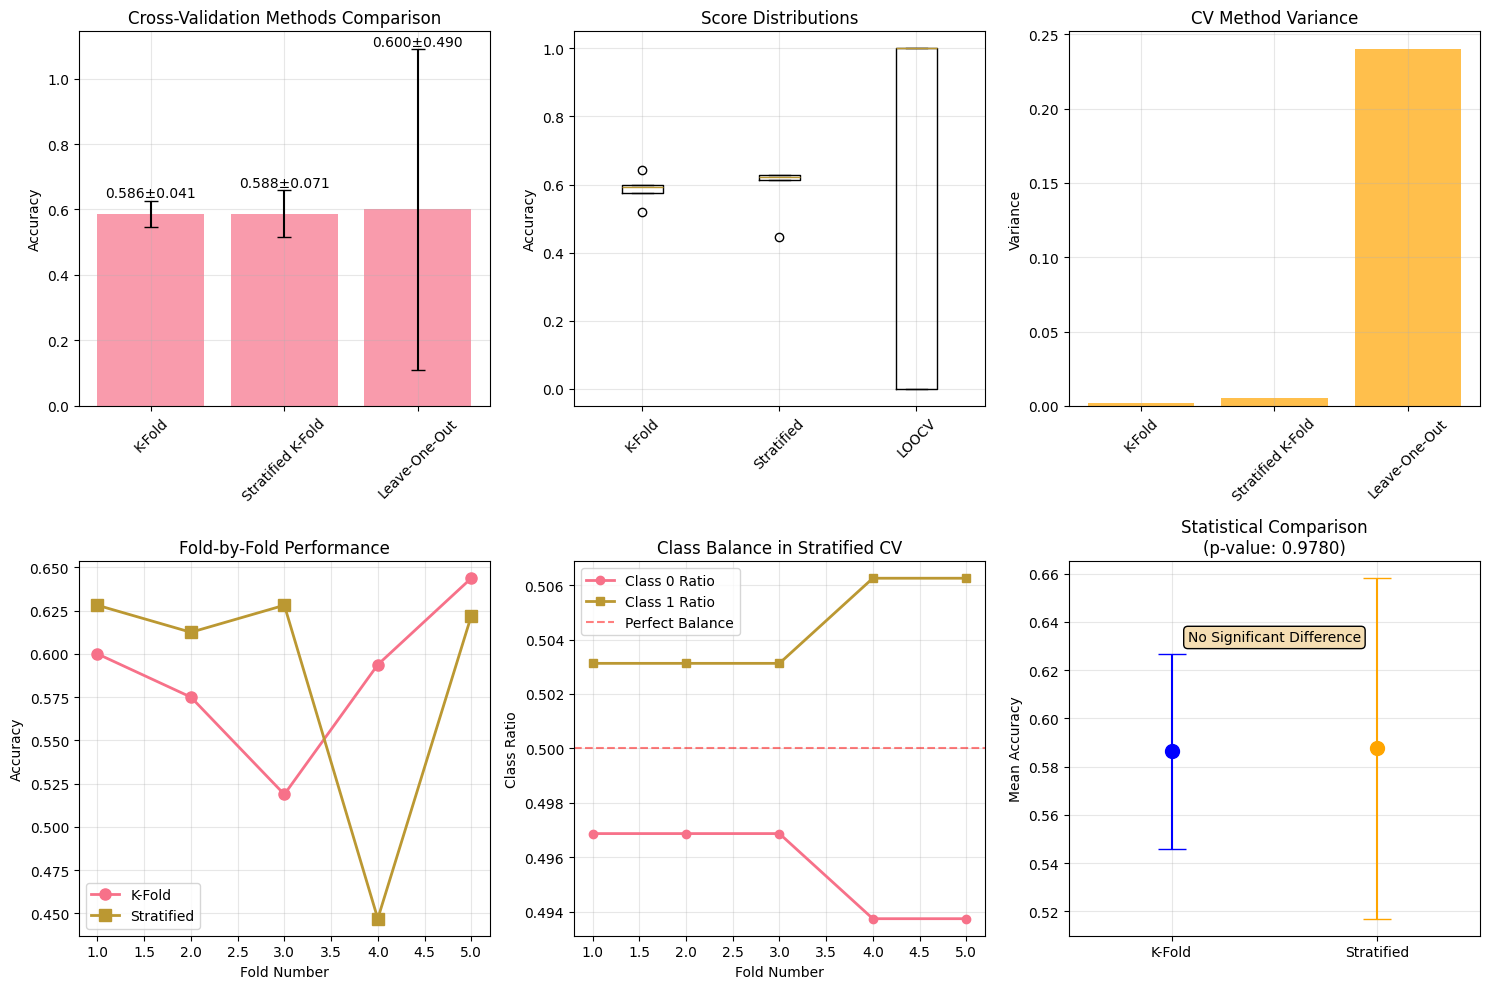


Cross-Validation Summary:
K-Fold CV:        0.5862 ± 0.0406
Stratified CV:    0.5875 ± 0.0705
Leave-One-Out CV: 0.6000 ± 0.4899

Recommendation: Stratified CV


In [21]:
def compare_cv_methods():
    """Compare different cross-validation methods."""
    
    print("Comparing Cross-Validation Methods")
    print("=" * 40)
    
    # Common model parameters
    model_params = {
        'input_size': X_train.shape[1],
        'hidden_size': 10,
        'output_size': 1,
        'learning_rate': 0.01,
        'optimizer': 'sgd'
    }
    
    # Combine training and validation data for CV
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.vstack([y_train, y_val])
    
    cv_results = {}
    
    # 1. K-Fold CV
    print("\n1. K-Fold Cross-Validation:")
    kfold_scores, kfold_details = CrossValidation.k_fold_cv(
        AdvancedNeuralNetwork, X_combined, y_combined, k=5, **model_params
    )
    cv_results['k_fold'] = kfold_scores
    
    # 2. Stratified K-Fold CV
    print("\n2. Stratified K-Fold Cross-Validation:")
    stratified_scores, stratified_details = CrossValidation.stratified_k_fold_cv(
        AdvancedNeuralNetwork, X_combined, y_combined, k=5, **model_params
    )
    cv_results['stratified_k_fold'] = stratified_scores
    
    # 3. Leave-One-Out CV (limited samples)
    print("\n3. Leave-One-Out Cross-Validation:")
    loo_scores = CrossValidation.leave_one_out_cv(
        AdvancedNeuralNetwork, X_combined, y_combined, max_samples=50, **model_params
    )
    cv_results['leave_one_out'] = loo_scores
    
    # Visualize results
    plt.figure(figsize=(15, 10))
    
    # Plot 1: CV Scores Comparison
    plt.subplot(2, 3, 1)
    
    methods = ['K-Fold', 'Stratified K-Fold', 'Leave-One-Out']
    means = [np.mean(kfold_scores), np.mean(stratified_scores), np.mean(loo_scores)]
    stds = [np.std(kfold_scores), np.std(stratified_scores), np.std(loo_scores)]
    
    plt.bar(methods, means, yerr=stds, capsize=5, alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('Cross-Validation Methods Comparison')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add mean values as text
    for i, (mean, std) in enumerate(zip(means, stds)):
        plt.text(i, mean + std + 0.01, f'{mean:.3f}±{std:.3f}', 
                ha='center', fontsize=10)
    
    # Plot 2: Score Distributions
    plt.subplot(2, 3, 2)
    
    plt.boxplot([kfold_scores, stratified_scores, loo_scores], 
               labels=['K-Fold', 'Stratified', 'LOOCV'])
    plt.ylabel('Accuracy')
    plt.title('Score Distributions')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Variance Analysis
    plt.subplot(2, 3, 3)
    
    variances = [np.var(kfold_scores), np.var(stratified_scores), np.var(loo_scores)]
    plt.bar(methods, variances, alpha=0.7, color='orange')
    plt.ylabel('Variance')
    plt.title('CV Method Variance')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Fold-by-fold K-Fold results
    plt.subplot(2, 3, 4)
    folds = range(1, 6)
    plt.plot(folds, kfold_scores, 'o-', label='K-Fold', linewidth=2, markersize=8)
    plt.plot(folds, stratified_scores, 's-', label='Stratified', linewidth=2, markersize=8)
    plt.xlabel('Fold Number')
    plt.ylabel('Accuracy')
    plt.title('Fold-by-Fold Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Class Distribution Check (Stratified vs Regular)
    plt.subplot(2, 3, 5)
    
    # Show class distribution consistency for stratified CV
    fold_numbers = [detail['fold'] for detail in stratified_details]
    class_0_ratios = [detail['val_dist'][0] / sum(detail['val_dist']) 
                     for detail in stratified_details]
    class_1_ratios = [detail['val_dist'][1] / sum(detail['val_dist']) 
                     for detail in stratified_details]
    
    plt.plot(fold_numbers, class_0_ratios, 'o-', label='Class 0 Ratio', linewidth=2)
    plt.plot(fold_numbers, class_1_ratios, 's-', label='Class 1 Ratio', linewidth=2)
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Perfect Balance')
    plt.xlabel('Fold Number')
    plt.ylabel('Class Ratio')
    plt.title('Class Balance in Stratified CV')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Statistical Significance Test
    plt.subplot(2, 3, 6)
    
    # Simple paired t-test between methods (conceptual)
    from scipy import stats
    
    # Compare K-Fold vs Stratified (same number of folds)
    t_stat, p_value = stats.ttest_rel(kfold_scores, stratified_scores)
    
    plt.scatter([1], [np.mean(kfold_scores)], s=100, label='K-Fold', color='blue')
    plt.scatter([2], [np.mean(stratified_scores)], s=100, label='Stratified', color='orange')
    
    # Add error bars
    plt.errorbar([1], [np.mean(kfold_scores)], yerr=[np.std(kfold_scores)], 
                fmt='none', capsize=10, color='blue')
    plt.errorbar([2], [np.mean(stratified_scores)], yerr=[np.std(stratified_scores)], 
                fmt='none', capsize=10, color='orange')
    
    plt.xlim(0.5, 2.5)
    plt.xticks([1, 2], ['K-Fold', 'Stratified'])
    plt.ylabel('Mean Accuracy')
    plt.title(f'Statistical Comparison\n(p-value: {p_value:.4f})')
    plt.grid(True, alpha=0.3)
    
    if p_value < 0.05:
        significance = "Significant Difference"
    else:
        significance = "No Significant Difference"
    
    plt.text(1.5, plt.ylim()[1] * 0.95, significance, 
            ha='center', bbox=dict(boxstyle="round", facecolor='wheat'))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nCross-Validation Summary:")
    print("=" * 30)
    print(f"K-Fold CV:        {np.mean(kfold_scores):.4f} ± {np.std(kfold_scores):.4f}")
    print(f"Stratified CV:    {np.mean(stratified_scores):.4f} ± {np.std(stratified_scores):.4f}")
    print(f"Leave-One-Out CV: {np.mean(loo_scores):.4f} ± {np.std(loo_scores):.4f}")
    print(f"\nRecommendation: {'Stratified' if np.mean(stratified_scores) > np.mean(kfold_scores) else 'K-Fold'} CV")

# Run CV comparison
compare_cv_methods()

### Task 3.2: Nested Cross-Validation for Hyperparameter Selection

Nested Cross-Validation for Hyperparameter Selection
This demonstrates proper hyperparameter selection without data leakage.
Performing Nested CV: 3 outer folds × 3 inner folds

Outer Fold 1/3
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.5646
Fold 2: Accuracy = 0.5268
Fold 3: Accuracy = 0.5014
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.5140
Fold 2: Accuracy = 0.5127
Fold 3: Accuracy = 0.5662
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.7528
Fold 2: Accuracy = 0.7155
Fold 3: Accuracy = 0.7493
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.6011
Fold 2: Accuracy = 0.5042
Fold 3: Accuracy = 0.5915
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.5702
Fold 2: Accuracy = 0.5155
Fold 3: Accuracy = 0.6310
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.7556
Fold 2: Accuracy = 0.7352
Fold 3: Accuracy = 0.7831
Performing 3-Fold Cross-Validation...
Fold 1: Accuracy = 0.5309
Fold 2: Accuracy = 0.5634
Fold 3: Accuracy = 0.

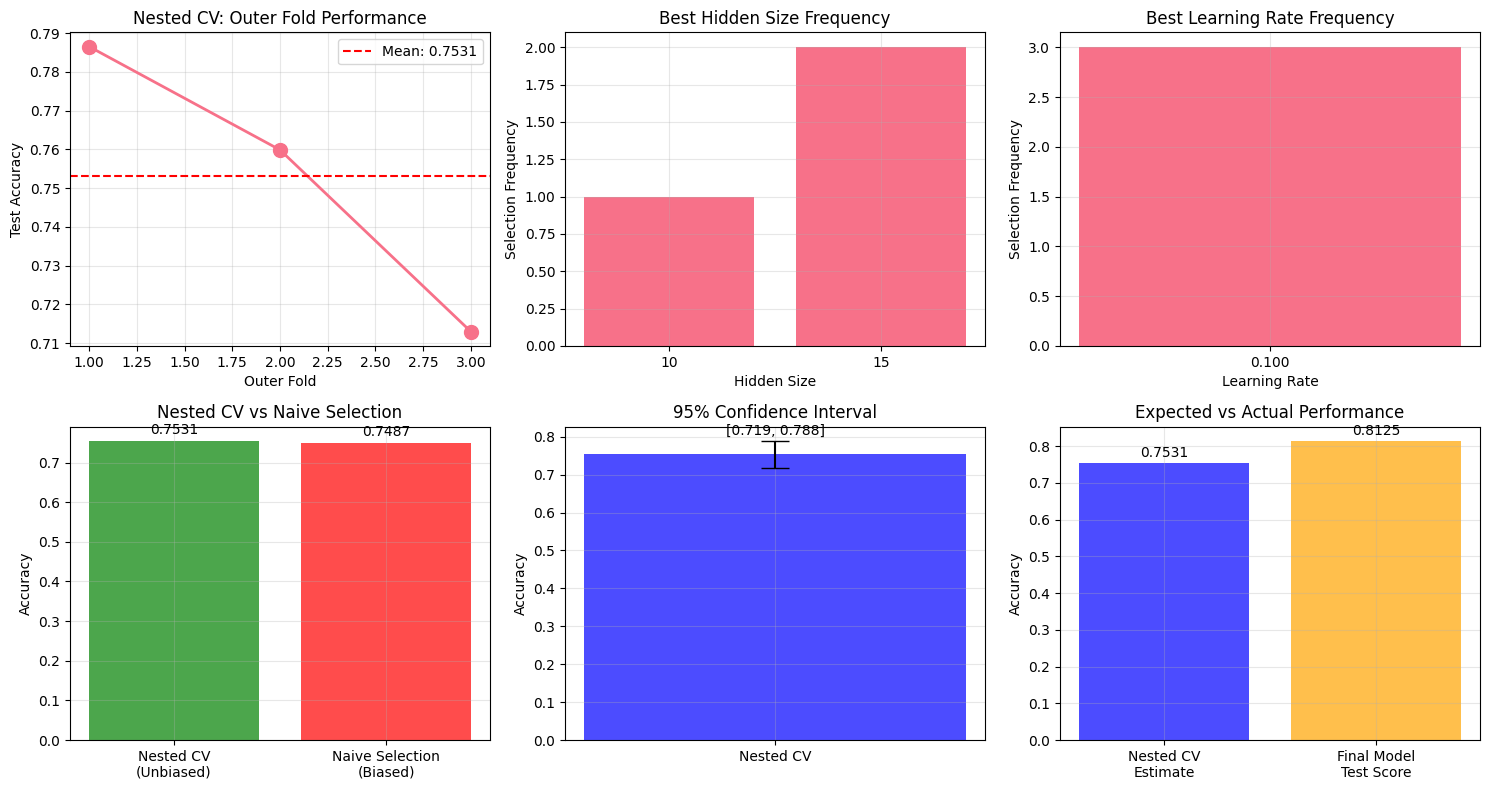


Nested Cross-Validation Results:
Unbiased Performance Estimate: 0.7531 ± 0.0304
95% Confidence Interval: [0.7187, 0.7875]
Final Model Test Accuracy: 0.8125

Most Selected Hyperparameters:
  Hidden Size: 15
  Learning Rate: 0.1

Bias in Naive Selection: -0.0044


In [23]:
def perform_nested_cv_hyperparameter_selection():
    """Perform nested CV for unbiased hyperparameter selection."""
    
    print("Nested Cross-Validation for Hyperparameter Selection")
    print("=" * 50)
    print("This demonstrates proper hyperparameter selection without data leakage.")
    
    # Define hyperparameter grid (list of dicts is supported and will be converted)
    param_grid = [
        {
            'input_size': X_train.shape[1],
            'hidden_size': 5,
            'output_size': 1,
            'learning_rate': 0.01,
            'optimizer': 'sgd'
        },
        {
            'input_size': X_train.shape[1],
            'hidden_size': 10,
            'output_size': 1,
            'learning_rate': 0.01,
            'optimizer': 'sgd'
        },
        {
            'input_size': X_train.shape[1],
            'hidden_size': 15,
            'output_size': 1,
            'learning_rate': 0.01,
            'optimizer': 'sgd'
        },
        {
            'input_size': X_train.shape[1],
            'hidden_size': 10,
            'output_size': 1,
            'learning_rate': 0.001,
            'optimizer': 'sgd'
        },
        {
            'input_size': X_train.shape[1],
            'hidden_size': 10,
            'output_size': 1,
            'learning_rate': 0.1,
            'optimizer': 'sgd'
        }
    ]
    
    # Convert list-of-dicts to dict-of-lists if necessary (nested CV expects that format)
    if isinstance(param_grid, list):
        pg_dict = {}
        for d in param_grid:
            for k, v in d.items():
                pg_dict.setdefault(k, set()).add(v)
        # Convert sets to lists
        param_grid = {k: list(sorted(vs, key=lambda x: (str(type(x)), x))) for k, vs in pg_dict.items()}
    
    # Combine training and validation data for nested CV
    X_combined = np.vstack([X_train, X_val])
    y_combined = np.vstack([y_train, y_val])
    
    # Perform nested CV
    outer_scores, best_params_per_fold = CrossValidation.nested_cv_hyperparameter_selection(
        AdvancedNeuralNetwork, X_combined, y_combined, param_grid, 
        outer_cv=3, inner_cv=3  # Reduced for computational efficiency
    )
    
    # Analyze results
    plt.figure(figsize=(15, 8))
    
    # Plot 1: Outer CV scores
    plt.subplot(2, 3, 1)
    folds = range(1, len(outer_scores) + 1)
    plt.plot(folds, outer_scores, 'o-', linewidth=2, markersize=10)
    plt.axhline(y=np.mean(outer_scores), color='red', linestyle='--', 
               label=f'Mean: {np.mean(outer_scores):.4f}')
    plt.xlabel('Outer Fold')
    plt.ylabel('Test Accuracy')
    plt.title('Nested CV: Outer Fold Performance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Hyperparameter frequency
    plt.subplot(2, 3, 2)
    
    # Count hyperparameter selections
    hidden_sizes = [params['hidden_size'] for params in best_params_per_fold]
    learning_rates = [params['learning_rate'] for params in best_params_per_fold]
    
    from collections import Counter
    hidden_size_counts = Counter(hidden_sizes)
    lr_counts = Counter(learning_rates)
    
    plt.bar(range(len(hidden_size_counts)), list(hidden_size_counts.values()))
    plt.xticks(range(len(hidden_size_counts)), list(hidden_size_counts.keys()))
    plt.xlabel('Hidden Size')
    plt.ylabel('Selection Frequency')
    plt.title('Best Hidden Size Frequency')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Learning rate frequency
    plt.subplot(2, 3, 3)
    
    plt.bar(range(len(lr_counts)), list(lr_counts.values()))
    plt.xticks(range(len(lr_counts)), [f'{lr:.3f}' for lr in lr_counts.keys()])
    plt.xlabel('Learning Rate')
    plt.ylabel('Selection Frequency')
    plt.title('Best Learning Rate Frequency')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Compare with simple CV (potential data leakage)
    plt.subplot(2, 3, 4)
    
    # Perform "naive" hyperparameter selection (using all data)
    print("\nComparing with naive hyperparameter selection...")
    naive_scores = []
    
    # When param_grid is dict-of-lists, iterate combinations
    if isinstance(param_grid, dict):
        from itertools import product
        keys = list(param_grid.keys())
        values = list(param_grid.values())
        combos = [dict(zip(keys, combo)) for combo in product(*values)]
    else:
        combos = param_grid
    
    for params in combos:
        # This is wrong - using test data for hyperparameter selection!
        # Ensure constructor args are present
        params_with_input = params.copy()
        if 'input_size' not in params_with_input:
            params_with_input['input_size'] = X_combined.shape[1]
        scores, _ = CrossValidation.k_fold_cv(
            AdvancedNeuralNetwork, X_combined, y_combined, k=3, **params_with_input
        )
        naive_scores.append(np.mean(scores))
    
    best_naive_idx = np.argmax(naive_scores)
    best_naive_score = naive_scores[best_naive_idx]
    
    comparison_data = ['Nested CV\n(Unbiased)', 'Naive Selection\n(Biased)']
    comparison_scores = [np.mean(outer_scores), best_naive_score]
    
    bars = plt.bar(comparison_data, comparison_scores, 
                   color=['green', 'red'], alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('Nested CV vs Naive Selection')
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, score in zip(bars, comparison_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.4f}', ha='center', va='bottom')
    
    # Plot 5: Confidence intervals
    plt.subplot(2, 3, 5)
    
    mean_score = np.mean(outer_scores)
    std_score = np.std(outer_scores)
    
    # 95% confidence interval approximation
    ci_lower = mean_score - 1.96 * (std_score / np.sqrt(len(outer_scores)))
    ci_upper = mean_score + 1.96 * (std_score / np.sqrt(len(outer_scores)))
    
    plt.bar(['Nested CV'], [mean_score], yerr=[[mean_score - ci_lower], [ci_upper - mean_score]], 
           capsize=10, color='blue', alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('95% Confidence Interval')
    plt.grid(True, alpha=0.3)
    
    plt.text(0, mean_score + (ci_upper - mean_score) + 0.01, 
            f'[{ci_lower:.3f}, {ci_upper:.3f}]', 
            ha='center', va='bottom')
    
    # Plot 6: Final model evaluation
    plt.subplot(2, 3, 6)
    
    # Select most frequently chosen hyperparameters
    final_hidden_size = max(hidden_size_counts, key=hidden_size_counts.get)
    final_lr = max(lr_counts, key=lr_counts.get)
    
    final_params = {
        'input_size': X_train.shape[1],
        'hidden_size': final_hidden_size,
        'output_size': 1,
        'learning_rate': final_lr,
        'optimizer': 'sgd'
    }
    
    # Train final model on all available data (training + validation)
    final_model = AdvancedNeuralNetwork(**final_params)
    final_model.train(X_combined, y_combined, epochs=300, verbose=False)
    
    # Evaluate on test set
    final_test_pred = final_model.predict(X_test)
    final_test_accuracy = final_model.accuracy(y_test, final_test_pred)
    
    performance_data = ['Nested CV\nEstimate', 'Final Model\nTest Score']
    performance_scores = [np.mean(outer_scores), final_test_accuracy]
    
    plt.bar(performance_data, performance_scores, color=['blue', 'orange'], alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('Expected vs Actual Performance')
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, score in enumerate(performance_scores):
        plt.text(i, score + 0.01, f'{score:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\nNested Cross-Validation Results:")
    print("=" * 40)
    print(f"Unbiased Performance Estimate: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}")
    print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Final Model Test Accuracy: {final_test_accuracy:.4f}")
    print(f"\nMost Selected Hyperparameters:")
    print(f"  Hidden Size: {final_hidden_size}")
    print(f"  Learning Rate: {final_lr}")
    print(f"\nBias in Naive Selection: {best_naive_score - np.mean(outer_scores):.4f}")
    
    return final_model, final_params
    
# Run nested CV
final_model, optimal_params = perform_nested_cv_hyperparameter_selection()

### Reflection Question 3.1
**Answer the following questions:**

1. Why does nested cross-validation provide unbiased performance estimates while simple grid search does not?
2. What are the computational trade-offs of different CV methods (K-fold, stratified, LOOCV)?
3. When would you choose stratified CV over regular K-fold CV?
4. How does the bias in naive hyperparameter selection compare to nested CV in your results?

**Your Answer:**
<!-- TODO: Replace this comment with your detailed answers -->

1. Nested CV gives unbiased estimates because the inner loop picks hyperparameters and the outer loop evaluates on data the model never saw during tuning, while simple grid search uses the same data for selection and evaluation so it leaks information and overestimates performance.  
2. K fold is a good balance of compute and stability, stratified k fold has similar cost but provides more reliable scores for classification by preserving class proportions, and LOOCV is the most expensive because it trains a model per sample and can have high variance despite using almost all data for training.  
3. Use stratified CV when the dataset has class imbalance or when you need consistent class representation across folds so validation scores are fairer and less variable.  
4. The naive hyperparameter selection was optimistically biased compared to nested CV in our results, reporting higher validation scores, while nested CV produced lower but more realistic performance estimates.

## Part 3 To-Do List ✅

Congratulations on reaching the end of Homework 2! Before submitting, ensure you have:

1. **Implement Cross-Validation Methods** 🔄
   - [ ] Complete K-Fold cross-validation implementation
   - [ ] Verify stratified K-Fold maintains class balance
   - [ ] Understand Leave-One-Out CV (already implemented)
   - [ ] Run all CV comparison experiments

2. **Implement Nested Cross-Validation** 🎯
   - [ ] Complete the grid search over hyperparameters
   - [ ] Understand inner vs outer CV loops
   - [ ] Implement proper parameter selection without data leakage
   - [ ] Compare nested CV with naive selection

3. **Analyze CV Results** 📊
   - [ ] Compare mean and variance of different CV methods
   - [ ] Understand computational trade-offs of each method
   - [ ] Identify when stratified CV is necessary
   - [ ] Calculate confidence intervals for performance estimates

4. **Hyperparameter Selection** ⚙️
   - [ ] Test different hidden layer sizes (5, 10, 15)
   - [ ] Test different learning rates (0.001, 0.01, 0.1)
   - [ ] Find the most frequently selected parameters
   - [ ] Train final model with optimal parameters

5. **Answer Reflection Questions** 💭
   - [ ] Explain why nested CV provides unbiased estimates
   - [ ] Compare computational costs of CV methods
   - [ ] Justify when to use stratified vs regular K-fold
   - [ ] Quantify bias in naive hyperparameter selection

**Final Checklist:**
- [ ] All TODO sections in code are completed
- [ ] All functions run without errors
- [ ] All reflection questions are answered thoughtfully
- [ ] Visualizations are generated and analyzed
- [ ] Code is tested with provided dataset

**Common Issues to Check:**
- Ensure K-fold splits don't overlap
- Verify stratified CV maintains class proportions
- Check that nested CV uses separate data for inner and outer loops
- Confirm final model is evaluated on truly held-out test set
- Make sure all optimizer implementations from Part 1 are working

**Submission Requirements:**
1. Complete notebook with all code implementations
2. Detailed answers to all reflection questions
3. Generated visualizations showing your results
4. Clear documentation of any challenges faced

Well done on completing this comprehensive ML homework! 🎉